# In Class Activity April 14th, 2026

## Shane Waldron

In [ ]:
# pip install optuna

### Importing libraries, preparing data, initial EDA

In [1]:
# importing libraries (feel free to add more if you want to explore other things)
import numpy as np
import pandas as pd
import sweetviz as sv
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report
import optuna


In [2]:
# importing data
adult = pd.read_csv('adult.csv')
adult.head(20)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
6,29,?,227026,HS-grad,9,Never-married,?,Unmarried,Black,Male,0,0,40,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K


                                             |          | [  0%]   00:00 -> (? left)


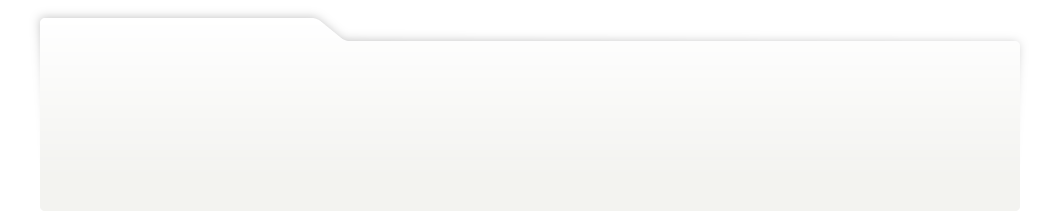
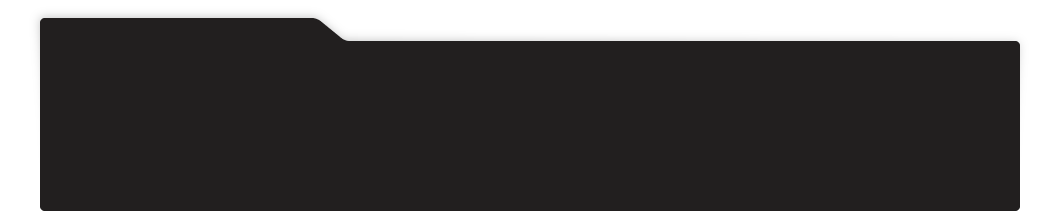
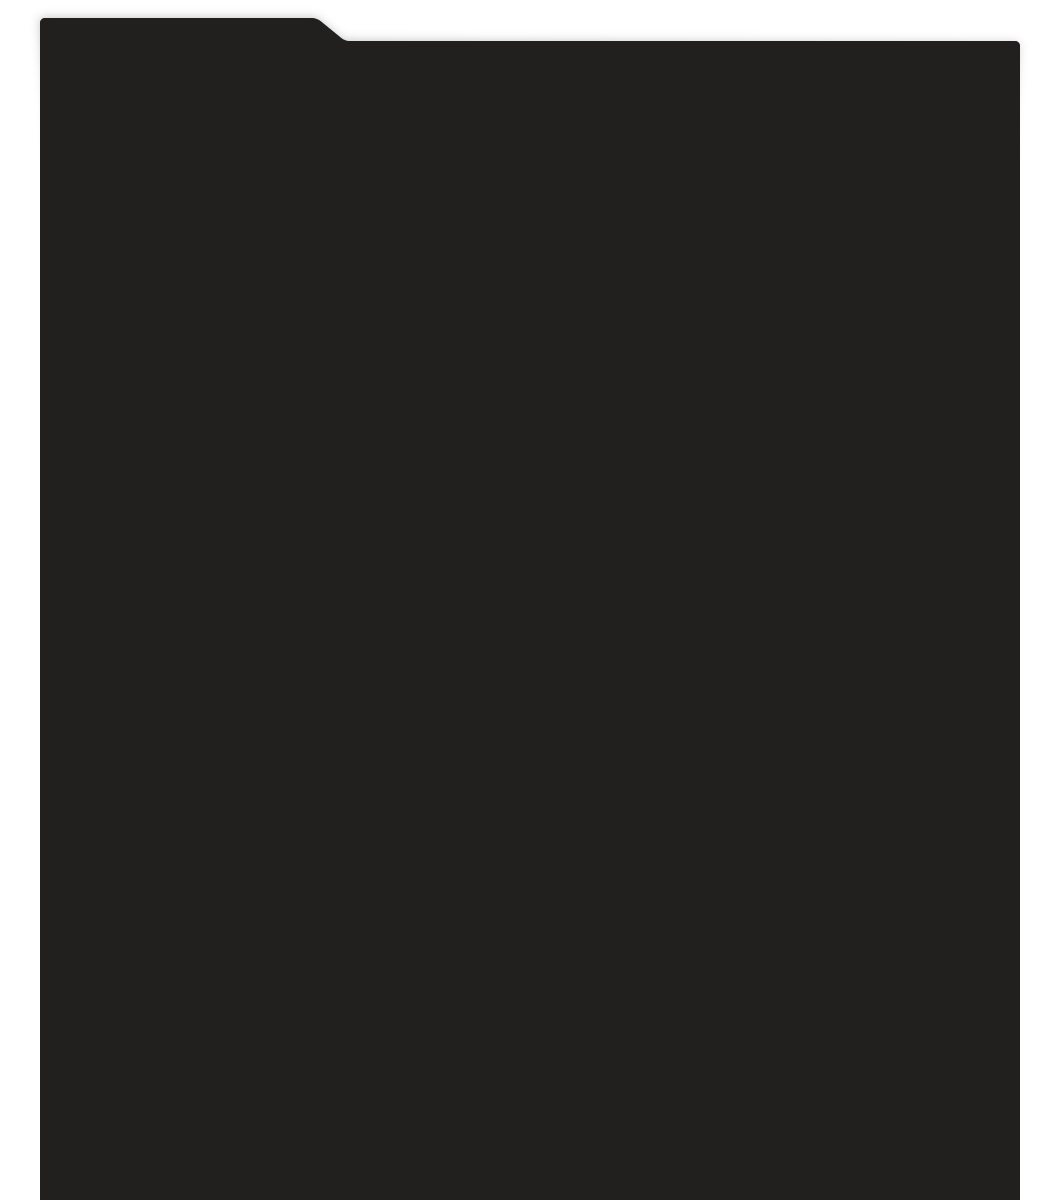
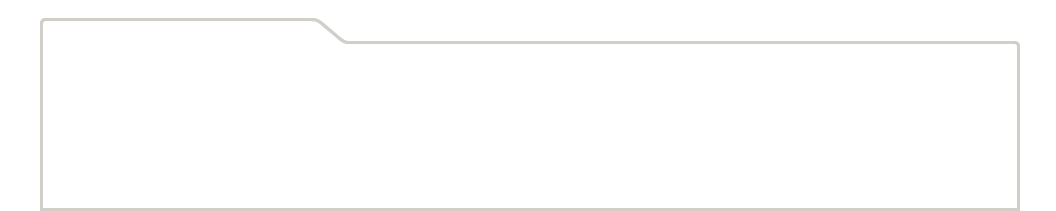
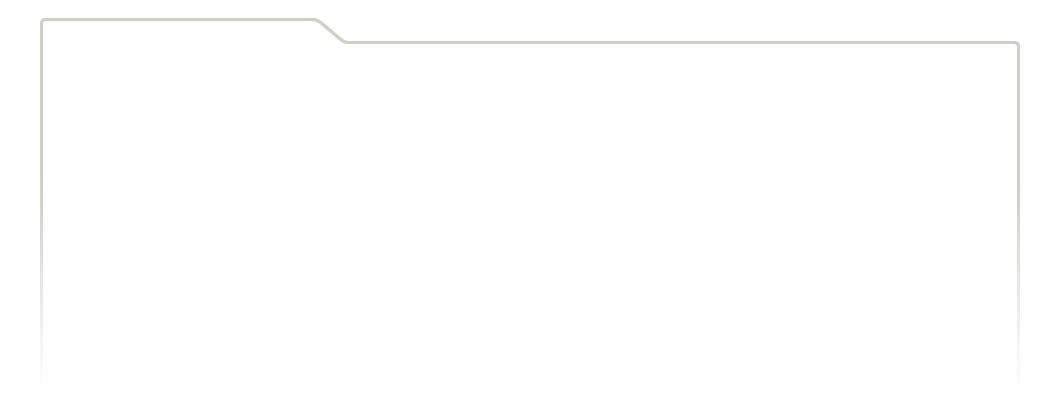
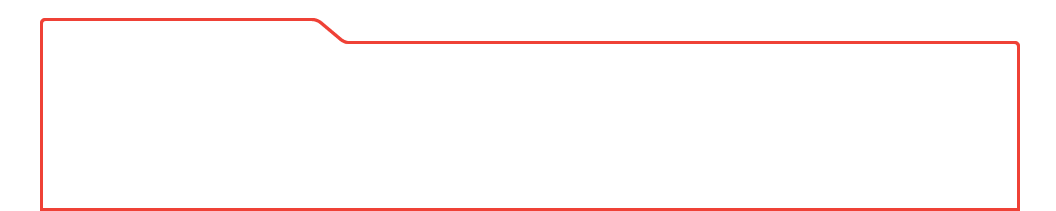
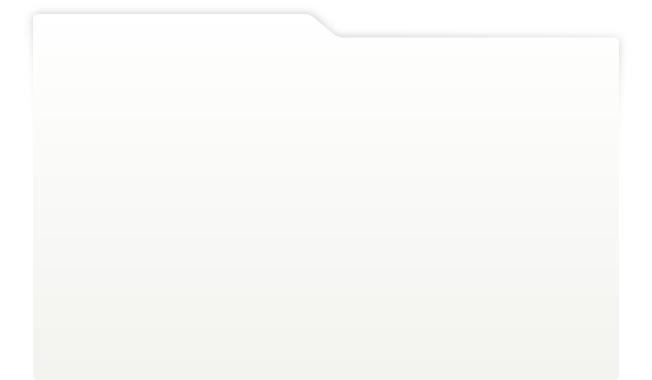
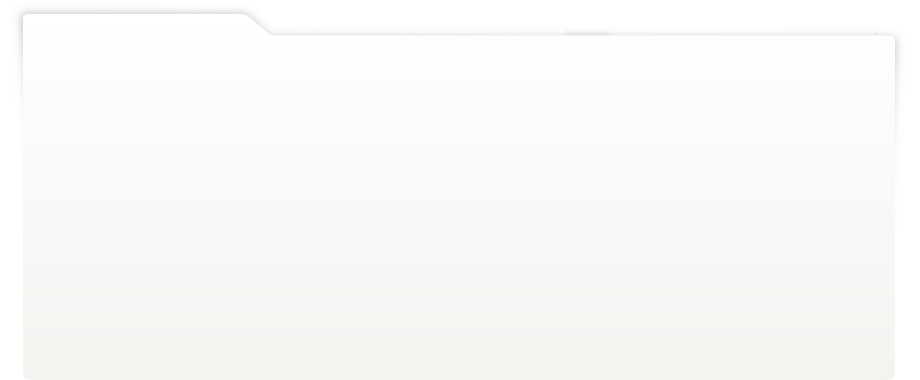
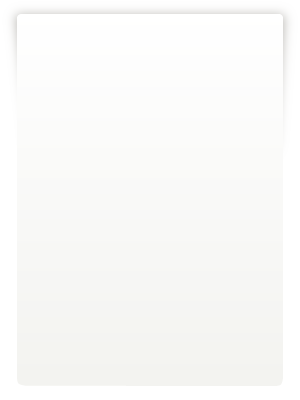
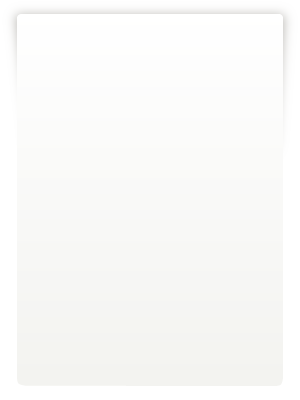
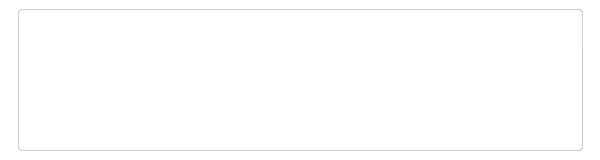
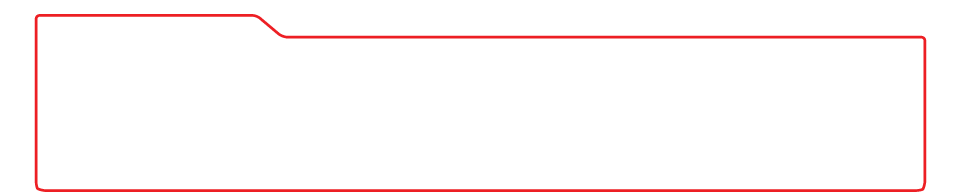
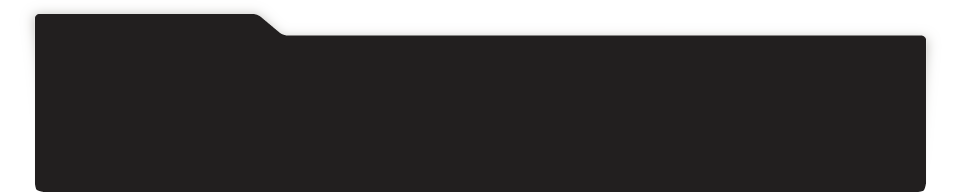
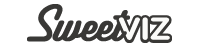
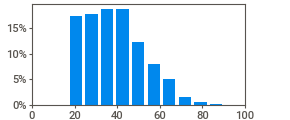
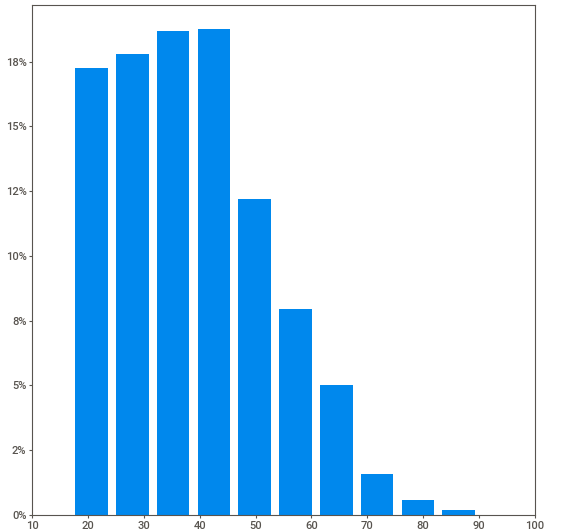
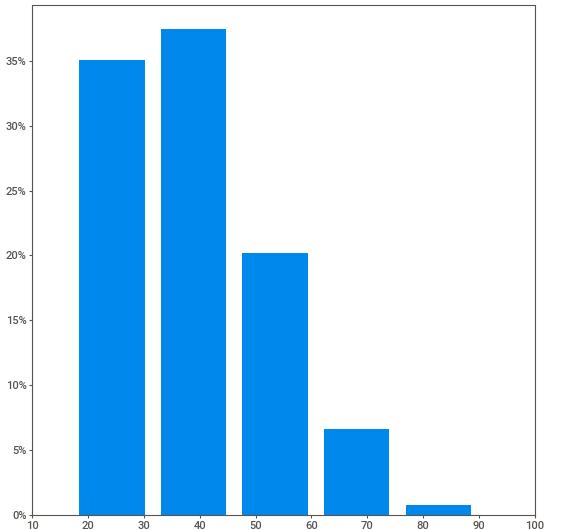
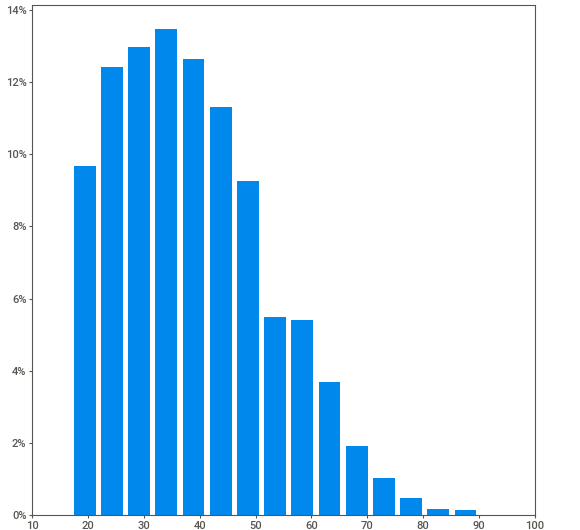
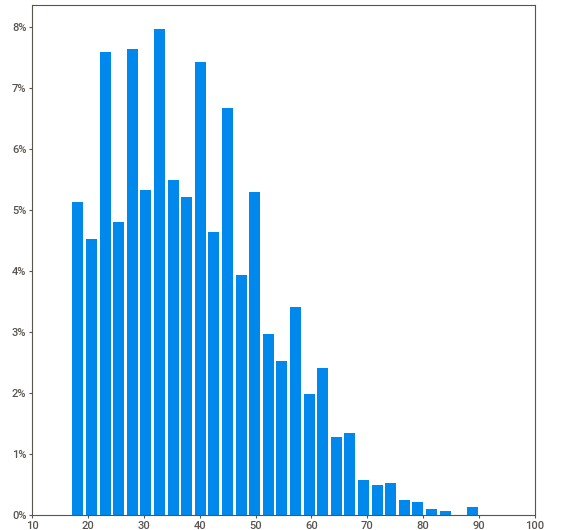
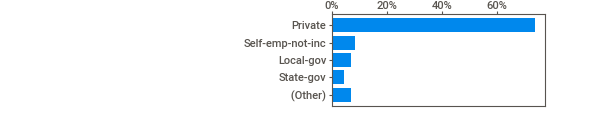
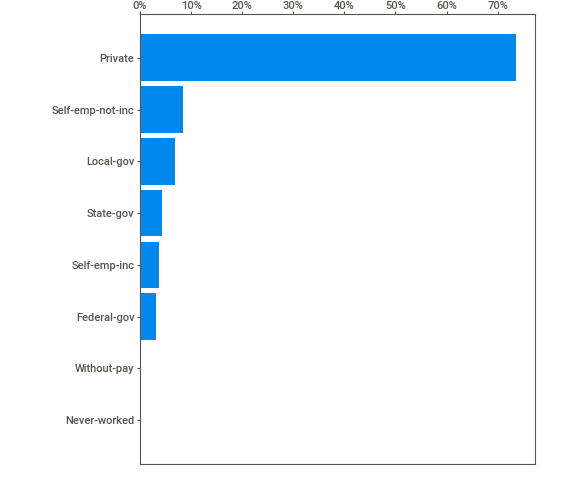
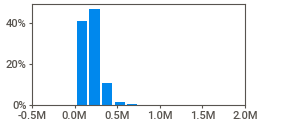
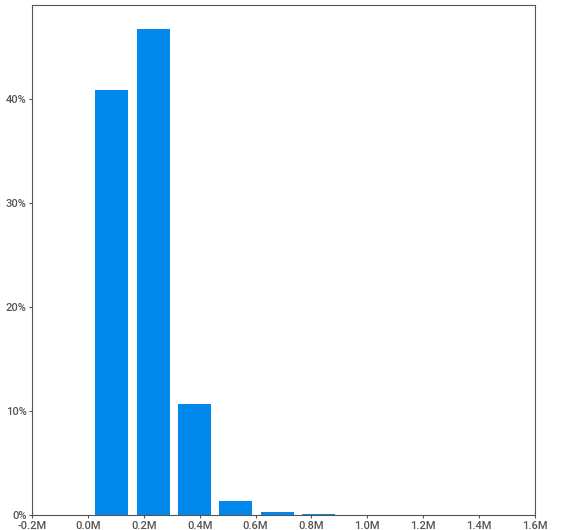
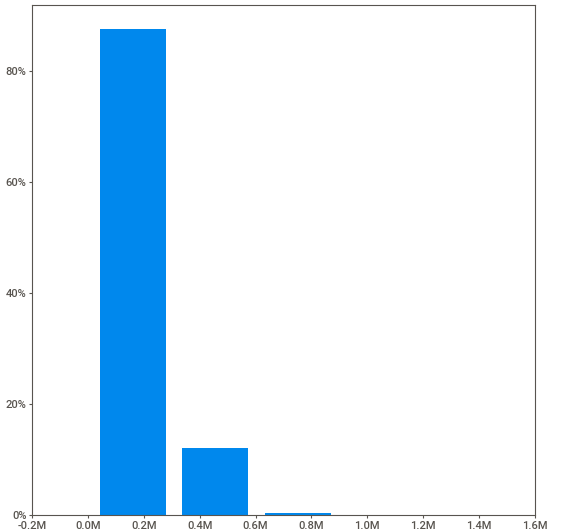
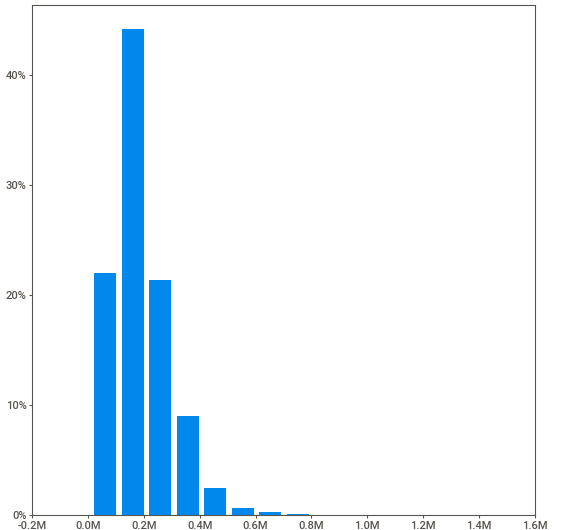
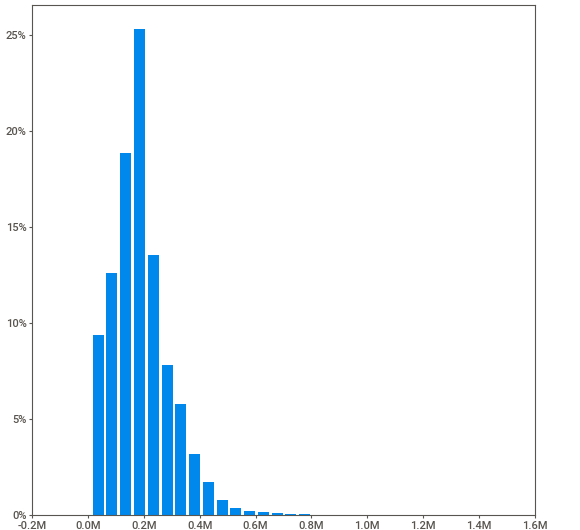
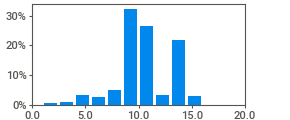
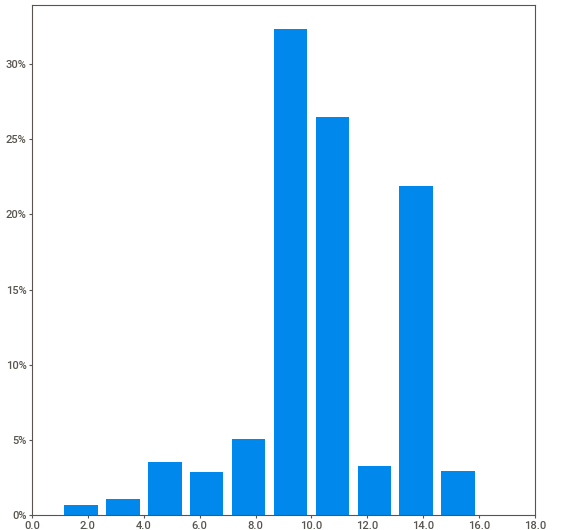
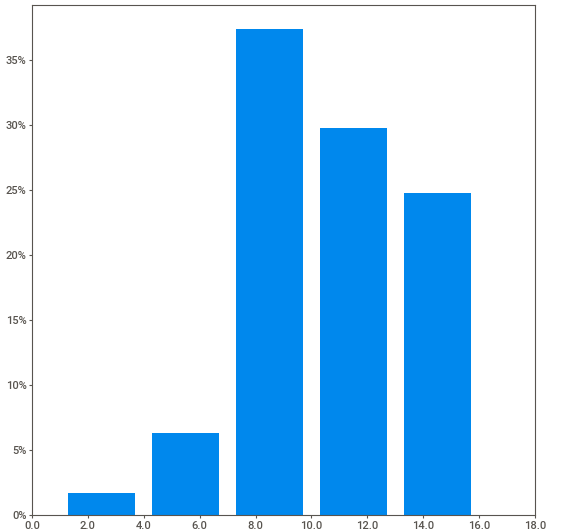
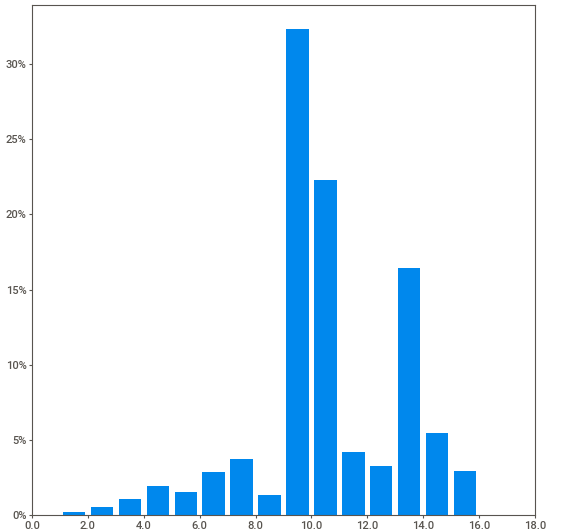
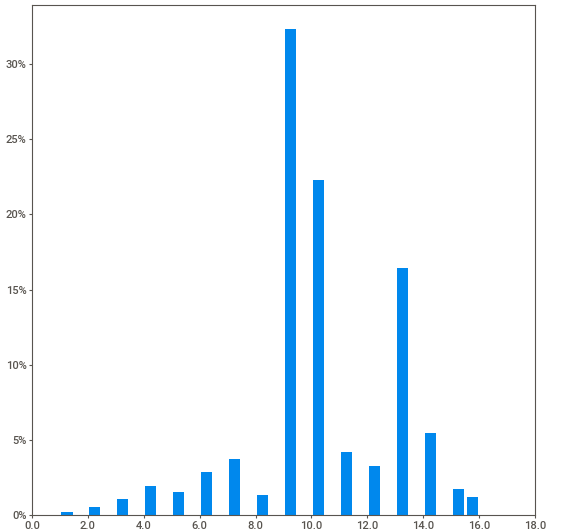
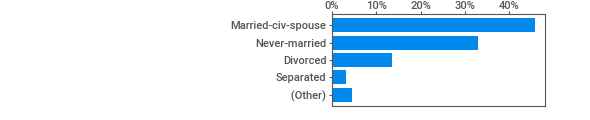
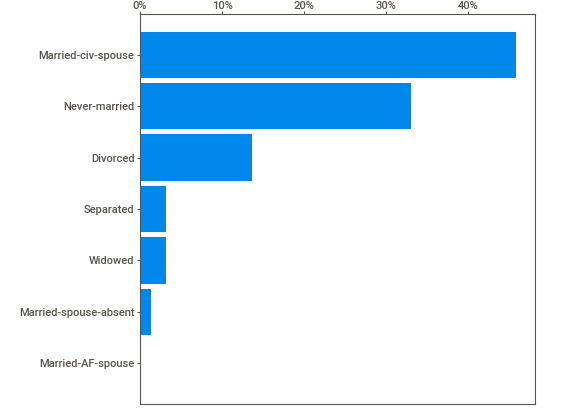
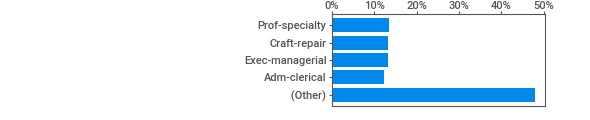
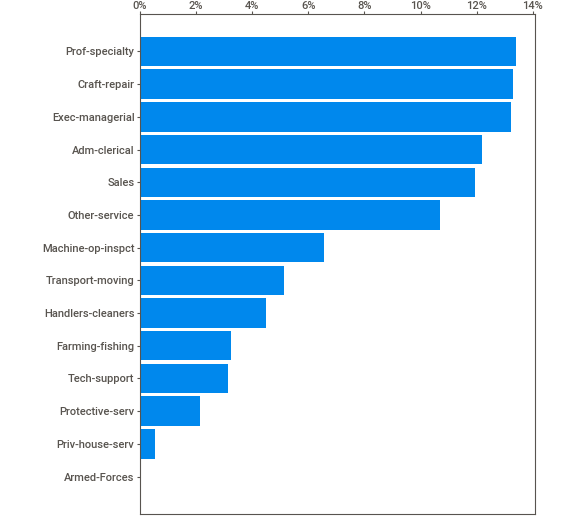
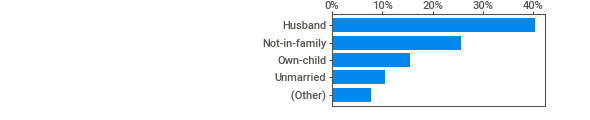
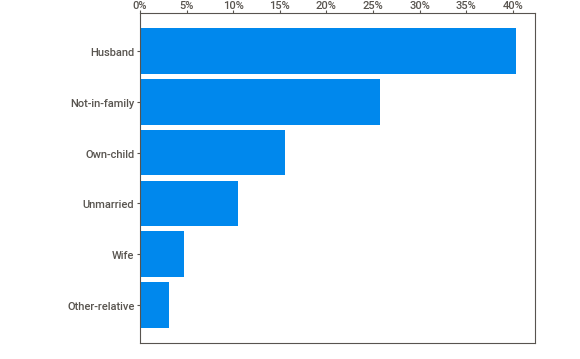
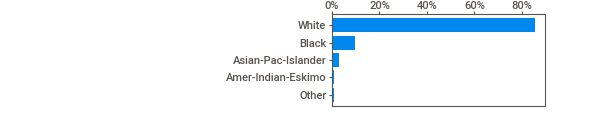
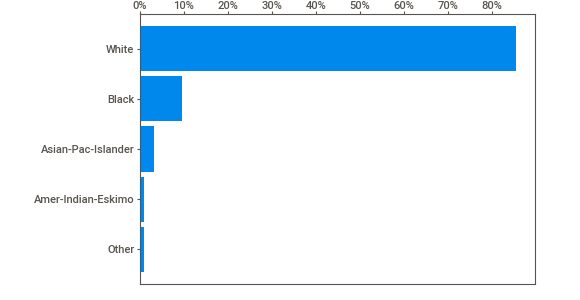
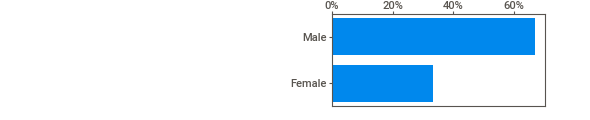
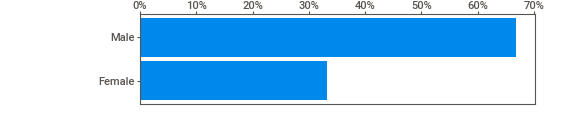
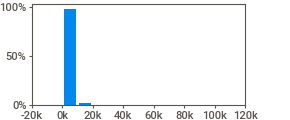
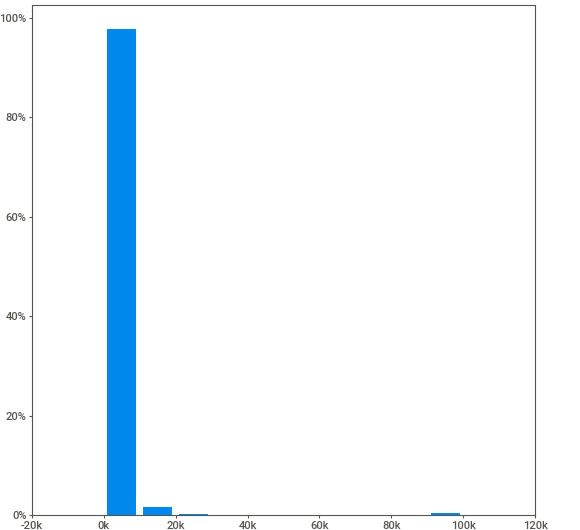
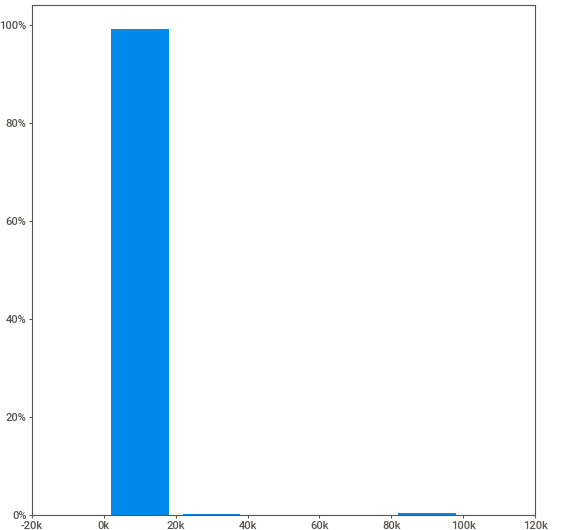
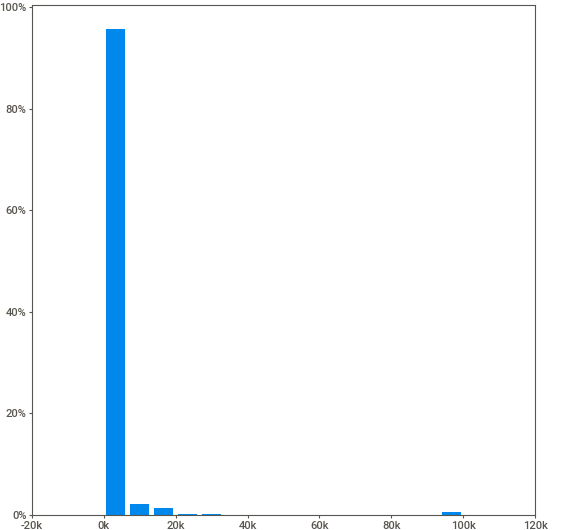
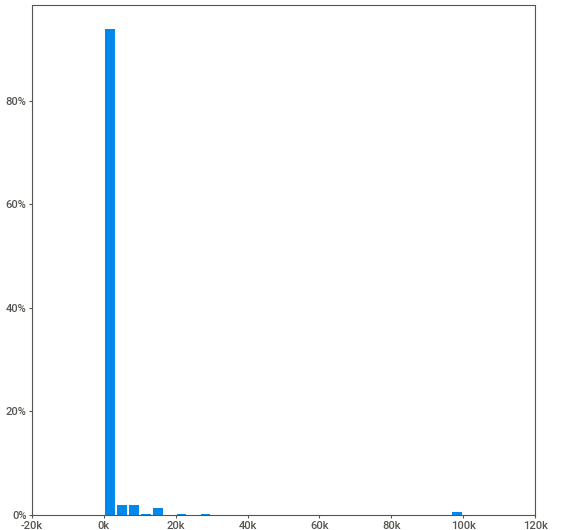
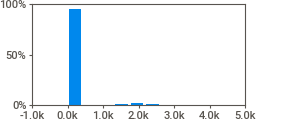
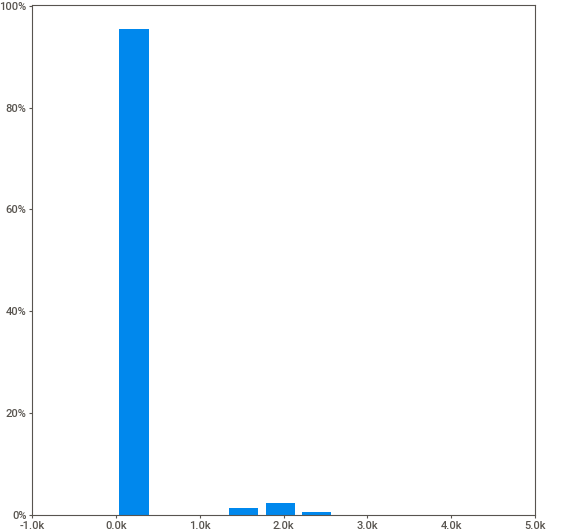
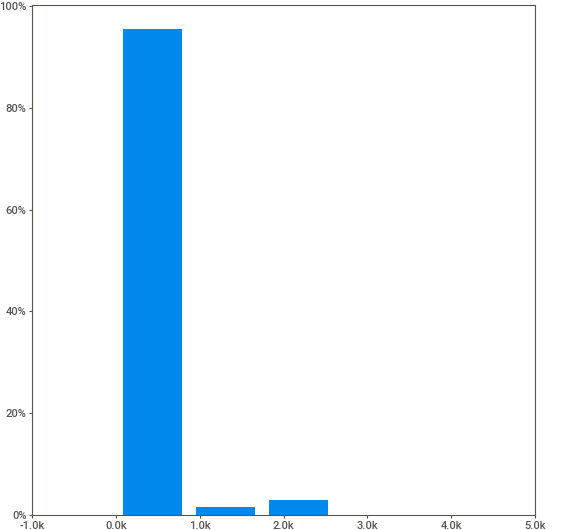
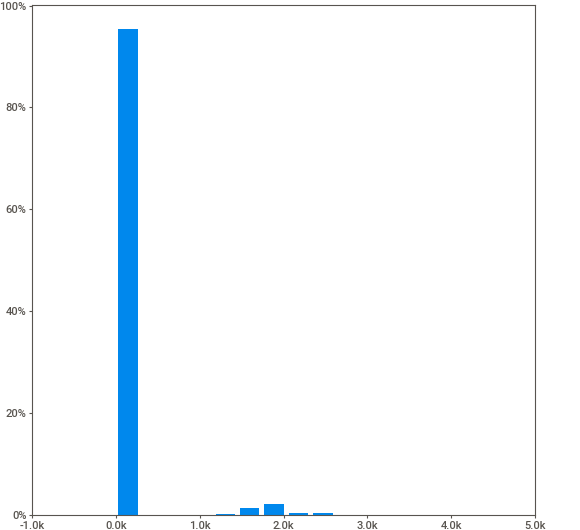
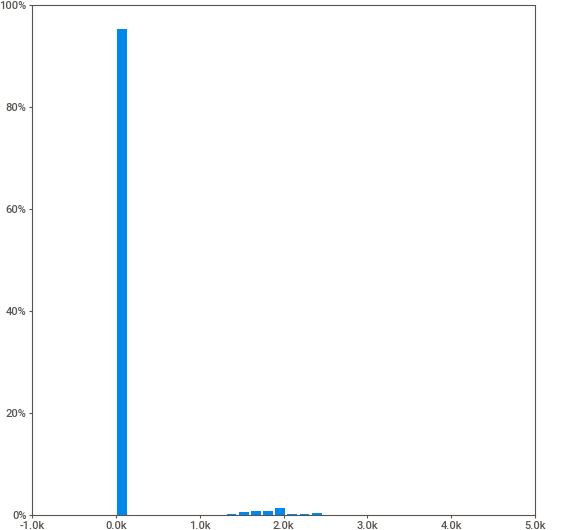
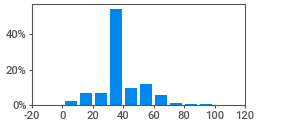
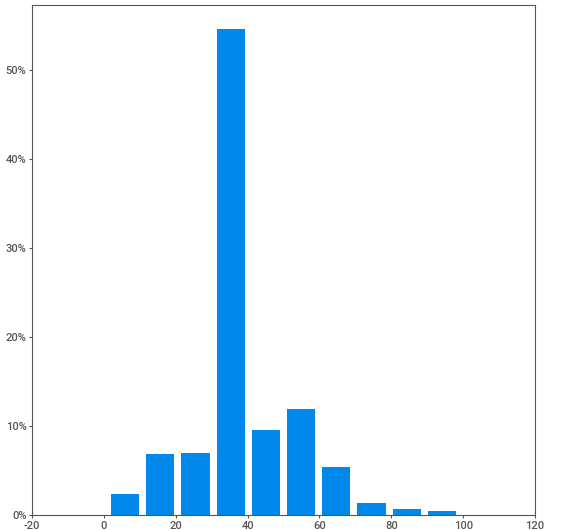
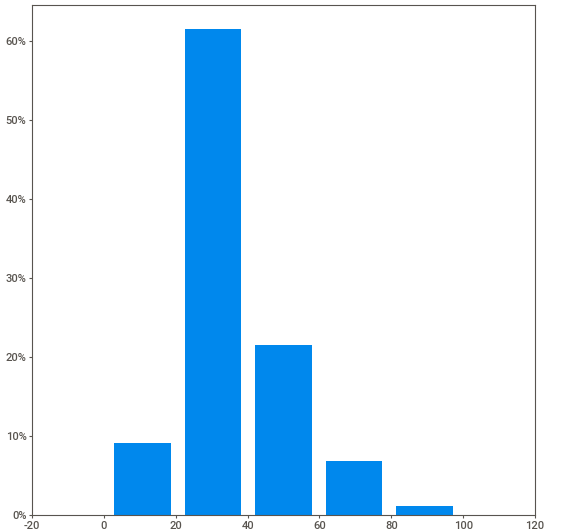
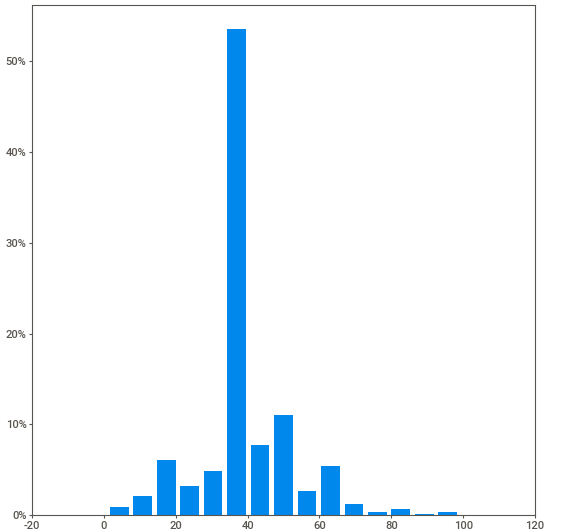
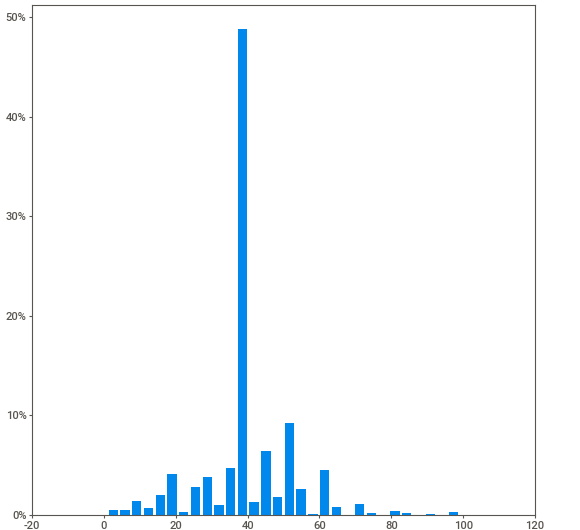
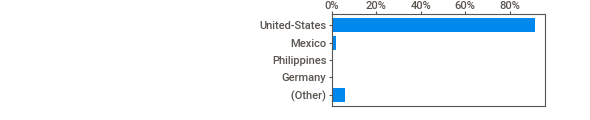
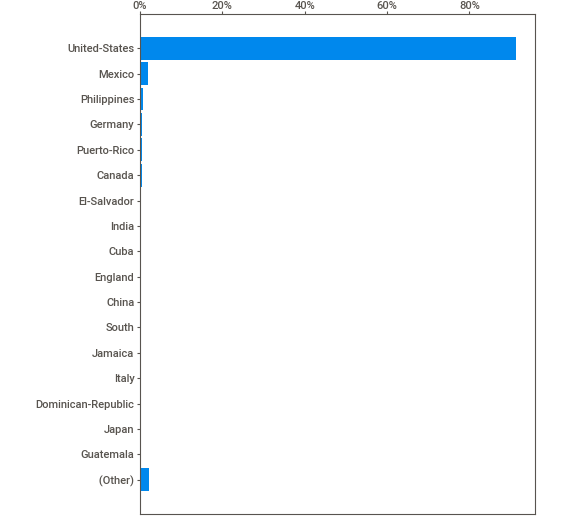
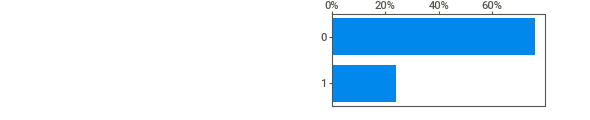
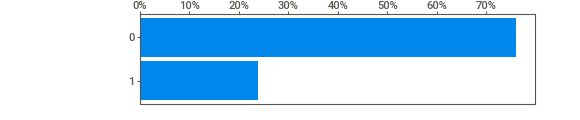
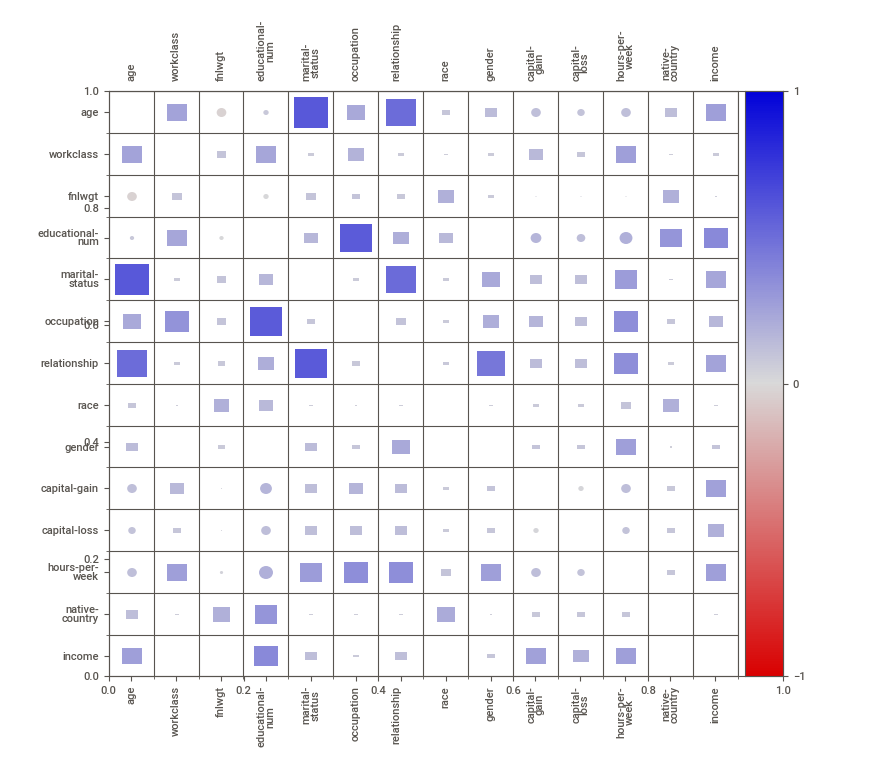
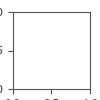

In [8]:
# initial EDA with sweetviz
report = sv.analyze(adult)
report.show_notebook()

# you are welcome to replace this cell with your own EDA, but make sure to include
# some visualizations and insights about the data


### In the markdown cell below describe what you learned from your EDA and how it will inform your modeling decisions





In terms of that target, income has some class imbalance so that will affect some of the model parameters, and the models shouldn't be evaluated on accuracy alone. There are some missing values that are encoded as question marks, so those should be converted to NaN values. Some predictors are more correlated with income than others such as education level and occopuation. There also is some skewness in some of the variables such as capital gain and capital loss. 

### Data Preprocessing (minimal) and Baseline Model

In [4]:
# data cleaning and preprocessing

# changing ? to NaN
adult = adult.replace('?', np.nan)

#education and education num are redundant, so we can drop one of them
adult = adult.drop('education', axis=1)

# target variable is income with 2 levels, so we can encode it as 0 and 1
adult['income'] = adult['income'].apply(lambda x: 1 if x == '>50K' else 0)

# change dtype categorical variables to category
categorical_cols = adult.select_dtypes(include='object').columns
adult[categorical_cols] = adult[categorical_cols].astype('category')


adult.head(20)

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,NaN,103497,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0
5,34,Private,198693,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,0
6,29,NaN,227026,9,Never-married,NaN,Unmarried,Black,Male,0,0,40,United-States,0
7,63,Self-emp-not-inc,104626,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,1
8,24,Private,369667,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,0
9,55,Private,104996,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,0


In [5]:
# defining features and target variable
X = adult.drop('income', axis=1)
y = adult['income']

# splitting data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, 
                                                    random_state=42, stratify=y)

In [6]:
# building xgboost default model and evaluating with stratified k-fold cross validation
xgb_cv = XGBClassifier(enable_categorical=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_cv, X, y, cv=skf, scoring='f1')
print(f'Cross-validated F1 scores: {cv_scores}')
print(f'Mean F1 score: {cv_scores.mean()}') 


Cross-validated F1 scores: [0.70680507 0.70892566 0.70898981 0.72424942 0.71086556]
Mean F1 score: 0.7119671046056588


### Use the markdown cell below to describe your baseline model performance and how you will try to improve it

I'll test out different parameters for the XGBoost model such as `scale_pos_weight` to see if adjusting for the class imbalance can help the performance of the model. Other parameters will be tested as well to see if the performance can be further improved from there, but I think adjusting for the class imbalance is the best first step.

### Model feature exploration

In the code cell below, explore different features of XGBoost and how they work (e.g. scale_pos_weight, max_depth, learning_rate).
Use stratified k-fold cross or repeated stratified k-fold cross validation with your model building. 
You should explore at least 3 different features of XGBoost.
Identify the model that performs best.

In [14]:
# Testing out different features of XGBoost with stratifed k-fold cross validation
# 1. scale_pos_weight
# 2. max_depth
# 3. learning_rate
# 4. n_estimators
xgb_cv = XGBClassifier(enable_categorical=True, random_state=42, scale_pos_weight=0.76/0.24)
cv_scores = cross_val_score(xgb_cv, X, y, cv=skf, scoring='f1')
print(f'Cross-validated F1 scores (scale_pos_weight=3.17): {cv_scores}')
print(f'Mean F1 score: {cv_scores.mean()}')

xgb_cv = XGBClassifier(enable_categorical=True, random_state=42, scale_pos_weight=0.76/0.24, max_depth=5)
cv_scores = cross_val_score(xgb_cv, X, y, cv=skf, scoring='f1')
print(f'Cross-validated F1 scores (max_depth=5 and scale_pos_weight=3.17): {cv_scores}')
print(f'Mean F1 score: {cv_scores.mean()}')

xgb_cv = XGBClassifier(enable_categorical=True, random_state=42, scale_pos_weight=0.76/0.24, max_depth=5, learning_rate=0.1)
cv_scores = cross_val_score(xgb_cv, X, y, cv=skf, scoring='f1')
print(f'Cross-validated F1 scores (learning_rate=0.1, max_depth=5 and scale_pos_weight=3.17): {cv_scores}')
print(f'Mean F1 score: {cv_scores.mean()}')

Cross-validated F1 scores (scale_pos_weight=3.17): [0.71506155 0.70984081 0.71586582 0.71838663 0.71144546]
Mean F1 score: 0.7141200535696768
Cross-validated F1 scores (max_depth=5 and scale_pos_weight=3.17): [0.71210762 0.70882458 0.7190127  0.72786411 0.7092324 ]
Mean F1 score: 0.7154082834206024
Cross-validated F1 scores (learning_rate=0.1, max_depth=5 and scale_pos_weight=3.17): [0.71194134 0.71031327 0.70947368 0.72288732 0.71038441]
Mean F1 score: 0.7130000067184972


The model with `max_depth = 5` and `scale_pos_weight = 3.17` performed the best with an f1 score of 0.715.

### Tuning with GridSearchCV

Use the code cell below to set up your parameter grid and run GridSearchCV with your preferred model from above. You should tune 4-5 hyperparameters utilizing cross validation. Train a final model using the best hyperparameters and report your model performance.

In [17]:
# Tuning with GridSearchCV
param_grid = {
    'scale_pos_weight': [0.76/0.24, 1, 2, 3, 4],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300]
}
xgb = XGBClassifier(enable_categorical=True, random_state=42)
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=skf, scoring='f1', n_jobs=-1)
grid_search.fit(X, y)
print(f'Best parameters from GridSearchCV: {grid_search.best_params_}')
print(f'Best F1 score from GridSearchCV: {grid_search.best_score_}')

# Classification report on test set with best parameters from GridSearchCV
best_xgb = grid_search.best_estimator_
best_xgb.fit(X_train, y_train)
y_pred = best_xgb.predict(X_test)
print(classification_report(y_test, y_pred))


Best parameters from GridSearchCV: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'scale_pos_weight': 2}
Best F1 score from GridSearchCV: 0.7288078457965205
              precision    recall  f1-score   support

           0       0.93      0.88      0.90      7431
           1       0.67      0.80      0.73      2338

    accuracy                           0.86      9769
   macro avg       0.80      0.84      0.82      9769
weighted avg       0.87      0.86      0.86      9769



The model performs moderately well, with a strong overall accuracy of 0.86. It does a good job identifying higher-income cases, with a recall of 0.80, but this comes with some false positives, reflected in the 0.67 precision. Lower-income cases are classified very well overall, with an F1 score of 0.90. Overall, the macro F1 of 0.82 suggests the model is reasonably balanced across both classes.

### Tuning with RandomizedSearchCV

Using the code cell below as a starting point, tune your preferred model from above. Tune the same 4-5 hyperparameters from above utilizing cross validation. Train a final model using the best hyperparameters and report your model performance.

In [16]:
# tuning xgboost classifier with RandomizedSearchCV (tune more parameters than shown here)
param_dist = {
    'scale_pos_weight': [0.76/0.24, 1, 2, 3, 4],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300]
}

# replace this placeholder model with your preferred model from above

xgb_random = RandomizedSearchCV(XGBClassifier(random_state=42, enable_categorical=True),
                                param_distributions=param_dist, n_iter=20, cv=skf, scoring='f1', random_state=42)
xgb_random.fit(X_train, y_train)
print(f'Best parameters from RandomizedSearchCV: {xgb_random.best_params_}')
print(f'Best F1 score from RandomizedSearchCV: {xgb_random.best_score_}')   

# build your preferred model from above using best parameters from your RandomizedSearchCV
# and evaluate on the test set

xgb_random_best = XGBClassifier(random_state=42, scale_pos_weight=xgb_random.best_params_['scale_pos_weight'], 
                                max_depth=xgb_random.best_params_['max_depth'], 
                                learning_rate=xgb_random.best_params_['learning_rate'], 
                                n_estimators=xgb_random.best_params_['n_estimators'],
                                enable_categorical=True)
xgb_random_best.fit(X_train, y_train)
y_pred_random = xgb_random_best.predict(X_test)
print(f'Classification report for RandomizedSearchCV-tuned model:\n{classification_report(y_test, y_pred_random)}')


Best parameters from RandomizedSearchCV: {'scale_pos_weight': 2, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
Best F1 score from RandomizedSearchCV: 0.7286942478730701
Classification report for RandomizedSearchCV-tuned model:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90      7431
           1       0.67      0.79      0.73      2338

    accuracy                           0.86      9769
   macro avg       0.80      0.84      0.82      9769
weighted avg       0.87      0.86      0.86      9769



The model performs moderately well, as the accuracy is quite high. The model is doing a good job of finding higher income cases with a recall of 0.79, but at the cost of allowing a good amount of false positives with a 0.67 precision. The lower income cases are strong overall with a 0.90 F1 score. Overall, the macro F1 of 0.82 indicates the model is reasonably balanced.

### Tuning with Optuna

Using the code cell below as a starting point, tune your preferred model from above. You should tune the same 4-5 parameters as above using cross validation. Train a final model using the best hyperparameters and report your model performance.

In [18]:
# tuning with Optuna (tune more parameters than shown here)
def objective(trial):
    scale_pos_weight = trial.suggest_float('scale_pos_weight', 1.0, 10.0)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    n_estimators = trial.suggest_int('n_estimators', 100, 300)
    
    # replace this placeholder model with your preferred model from above
    
    xgb_optuna = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight, 
                               max_depth=max_depth,  learning_rate=learning_rate, n_estimators=n_estimators, enable_categorical=True)
    
    cv_scores = cross_val_score(xgb_optuna, X, y, cv=skf, scoring='f1')
    return cv_scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f'Best parameters from Optuna: {study.best_params}')
print(f'Best F1 score from Optuna: {study.best_value}')

# build preferred model from above with best parameters from Optuna and evaluate on the test set
xgb_optuna_best = XGBClassifier(random_state=42, scale_pos_weight=study.best_params['scale_pos_weight'], 
                                  max_depth=study.best_params['max_depth'], 
                                  learning_rate=study.best_params['learning_rate'], 
                                  n_estimators=study.best_params['n_estimators'],
                                  enable_categorical=True)
xgb_optuna_best.fit(X_train, y_train)
y_pred_optuna = xgb_optuna_best.predict(X_test)
print(f'Classification report for Optuna-tuned model:\n{classification_report(y_test, y_pred_optuna)}')


[I 2026-04-14 21:42:23,949] A new study created in memory with name: no-name-c0fa9a79-4a9b-43c7-8436-4693f1c6bfcf


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-14 21:42:27,396] Trial 0 finished with value: 0.721428733307081 and parameters: {'scale_pos_weight': 1.9758798708948777, 'max_depth': 5, 'learning_rate': 0.26330033067365327, 'n_estimators': 297}. Best is trial 0 with value: 0.721428733307081.
[I 2026-04-14 21:42:31,266] Trial 1 finished with value: 0.7066352429347289 and parameters: {'scale_pos_weight': 2.3663309551286886, 'max_depth': 9, 'learning_rate': 0.2988423575420451, 'n_estimators': 188}. Best is trial 0 with value: 0.721428733307081.
[I 2026-04-14 21:42:34,319] Trial 2 finished with value: 0.6971379900757408 and parameters: {'scale_pos_weight': 6.088932671344326, 'max_depth': 10, 'learning_rate': 0.1858991400638397, 'n_estimators': 126}. Best is trial 0 with value: 0.721428733307081.
[I 2026-04-14 21:42:35,397] Trial 3 finished with value: 0.6556673754025117 and parameters: {'scale_pos_weight': 9.56699642099743, 'max_depth': 4, 'learning_rate': 0.22555789695907252, 'n_estimators': 107}. Best is trial 0 with value: 

The Optuna-tuned model performs moderately well, with a strong overall accuracy of 0.86. It does a good job identifying higher-income cases, with a recall of 0.78, though this comes with some false positives, reflected in the 0.69 precision. Lower-income cases are classified very well overall, with an F1 score of 0.91. Overall, the macro F1 of 0.82 suggests the model is reasonably balanced across both classes.

### Tuning results

In the markdown cell below describe your experience tuning with the different methods. Which produced the best results? Which do you prefer?


I think as of now I prefer Optuna, as I like the idea of it using past trials to inform future trials so with enough trials you can theoretically converge on that best set of parameters assuming they are within the range. It seems more adaptive than a grid or random search.